# **Penerapan Metode Naive Bayes Untuk Klasifikasi Kelancaran Menstruasi Berdasarkan Data Fisiologis**

> Proyek ini bertujuan mengembangkan model klasifikasi untuk memprediksi kelancaran menstruasi berdasarkan data fisiologis pasien. Permasalahan utama yang diatasi adalah identifikasi dini kondisi Heavy Menstrual Bleeding (HMB) yang dapat menjadi indikator gangguan kesehatan reproduksi. Dataset yang digunakan berasal dari penelitian kesehatan menstruasi dengan 2.937 sampel observasi dan 72 variabel awal yang mencakup data demografis, fisiologis, dan pola menstruasi.





# **`Pre-Processing`**
---






In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
df = pd.read_csv('cleaned_dataset.csv')

print(df.shape) # Menampilkan ukuran df (baris, kolom)

print(df.columns.tolist()) # Menampilkan nama semua kolom
print(df.index.tolist()) # Menampilkan nama semua baris

pd.set_option('display.max_columns', None) # Tampilkan semua kolom
pd.set_option('display.max_rows', None) # Tampilkan semua baris

df.head() # Menampilkan 5 baris pertama

(2937, 72)
['id', 'age', 'study_interval', 'day_in_study', 'phase', 'medications', 'bleeding_days', 'lh', 'estrogen', 'flow intensity', 'flow_color', 'appetite', 'exerciselevel', 'headaches', 'cramps', 'sorebreasts', 'fatigue', 'sleepissue', 'moodswing', 'stress', 'foodcravings', 'indigestion', 'bloating', 'sleep_start_day_in_study', 'sleep_start_timestamp', 'sleep_end_day_in_study', 'sleep_end_timestamp', 'temperature_samples', 'nightly_temperature', 'type', 'baseline_relative_sample_sum', 'baseline_relative_sample_sum_of_squares', 'baseline_relative_nightly_standard_deviation', 'baseline_relative_sample_standard_deviation', 'Height', 'weight', 'BMI', 'inter_cycle_length', 'cycle_variability', 'BBT', 'Cervical mucus code', 'phase.1', 'LH_result', 'pain_nrs', 'pain_location', 'mood', 'sleep_hours', 'activity_level', 'contraception_type', 'parity', 'comorbid_thyroid', 'comorbid_PCOS', 'day_from_last_menses', 'missing_mar_flag', 'missing_mnar_flag', 'pad_change_rate', 'hygiene_product_us

,id,age,study_interval,day_in_study,phase,medications,bleeding_days,lh,estrogen,flow intensity,flow_color,appetite,exerciselevel,headaches,cramps,sorebreasts,fatigue,sleepissue,moodswing,stress,foodcravings,indigestion,bloating,sleep_start_day_in_study,sleep_start_timestamp,sleep_end_day_in_study,sleep_end_timestamp,temperature_samples,nightly_temperature,type,baseline_relative_sample_sum,baseline_relative_sample_sum_of_squares,baseline_relative_nightly_standard_deviation,baseline_relative_sample_standard_deviation,Height,weight,BMI,inter_cycle_length,cycle_variability,BBT,Cervical mucus code,phase.1,LH_result,pain_nrs,pain_location,mood,sleep_hours,activity_level,contraception_type,parity,comorbid_thyroid,comorbid_PCOS,day_from_last_menses,missing_mar_flag,missing_mnar_flag,pad_change_rate,hygiene_product_used,access_to_clean_water,cultural_preferences,lag1_BBT,lag2_BBT,BBT_mean_7d,BBT_std_7d,heavy_bleeding_flag_proxy,anovulation_proxy,HMB_label,synthetic_augmented_flag,advice_text,advice_type,advice_source,advice_confidence,validator_flag
0,1,23,2022,1,Follicular,Panadol,0,2.9,94.2,Not at all,Not at all,Low,Low,High,Very Low/Little,Very Low/Little,High,Low,Very Low/Little,Moderate,Very Low/Little,Very Low/Little,Very Low/Little,1,00:08:00,1,10:25:30,414,34.616087,SKIN,-24.698824,860.405881,0.614422,1.276894,1.5,50.0,22.222222,28,2.540524,36.476320,Creamy,Follicular,Negative,2.000000,Not at all,Calm,5.450022,Moderate,Not at all,0,0,0,5,0,0.0,0.51,Not at all,1,Not at all,36.573508,36.577024,36.476320,0.082042,2.16,1,0.43,1,Follicular phase tip: it's a great time for hi...,monitoring,synthetic_augmented,0.69,0
1,1,23,2022,2,Follicular,Panadol,0,1.2,226.3,Not at all,Not at all,Low,Low,Very High,Very Low/Little,Very Low/Little,High,Very High,Very Low/Little,Moderate,Very Low/Little,Very Low/Little,Very Low/Little,1,23:54:00,2,07:10:00,258,33.780659,SKIN,-24.698824,860.405881,0.614422,1.276894,1.5,50.0,22.222222,28,1.117716,36.437712,Creamy,Follicular,Negative,2.000000,Not at all,Calm,8.529877,Moderate,Not at all,0,1,1,5,0,0.0,0.97,Not at all,0,Not at all,36.476320,36.577024,36.457016,0.027300,2.01,1,0.72,1,Follicular phase tip: it's a great time for hi...,monitoring,synthetic_augmented,0.69,0
2,1,23,2022,3,Follicular,Panadol,0,3.5,276.8,Not at all,Not at all,Very Low,Very Low,High,Very Low/Little,Very Low/Little,Very High,Very High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little,3,00:14:00,3,09:04:00,353,34.634929,SKIN,6.651304,1554.843599,0.487865,2.101622,1.5,50.0,22.222222,28,3.383048,36.421241,Creamy,Follicular,Negative,2.383249,Not at all,Calm,7.535181,Moderate,pill,1,0,0,5,0,0.0,0.94,Not at all,1,Not at all,36.437712,36.476320,36.445091,0.028271,2.58,1,0.24,1,Follicular phase tip: it's a great time for hi...,monitoring,synthetic_augmented,0.69,0
3,1,23,2022,4,Fertility,Not at all,0,1.8,322.1,Not at all,Not at all,Low,Low,Very Low/Little,Very Low/Little,Very Low/Little,High,Very High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little,4,00:12:30,4,07:42:00,446,34.050056,SKIN,-126.224891,1161.909368,0.424570,1.839029,1.5,50.0,22.222222,28,2.143160,36.574803,Clear,Fertility,Positive,3.000000,Not at all,Energetic,8.034222,Moderate,injectable,0,0,0,13,0,0.0,0.23,Not at all,1,Not at all,36.421241,36.437712,36.477519,0.068841,1.36,0,0.23,1,"If phase isn't clear, keep tracking symptoms —...",monitoring,synthetic_augmented,0.63,0
4,1,23,2022,5,Fertility,Not at all,0,4.6,244.9,Not at all,Not at all,Very Low,Very Low,Very Low/Little,Very Low/Little,Very Low/Little,High,High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little,6,00:22:00,6,06:38:00,269,34.223197,SKIN,0.000000,766.896151,0.368295,1.803428,1.5,50.0,22.222222,28,1.921467,36.556378,Clear,Fertility,Positive,4.306807,Not at all,Energetic,6.963052,Moderate,Not at all,1,0,0,13,0,0.0,0.70,Not at all,1,Not at all,36.574803,36.421241,36.493291,0.069268,2.67,0,0.36,1,"If phase isn't clear, keep tracking symptoms —...",monitoring,s

# **`Dataset Modeling`**

Untuk membentuk dataset akhir yang terdiri dari fitur input dan label biner sebelum proses pelatihan model.

In [ ]:
features = [
    'cycle_variability',
    'inter_cycle_length',
    'pad_change_rate',
    'BBT_mean_7d',
    'BMI'
]

In [ ]:
df.head().style \
    .set_properties(
        subset=features,
        **{
            'background-color': 'lightyellow',
            'color': 'black'
        }
    ) \
    .set_table_styles([
        {
            'selector': f'th.col_heading.level0.col{df.columns.get_loc(col)}',
            'props': [
                ('background-color', 'lightyellow'),
                ('color', 'black'),
                ('font-weight', 'bold')
            ]
        }
        for col in features
    ])


,id,age,study_interval,day_in_study,phase,medications,bleeding_days,lh,estrogen,flow intensity,flow_color,appetite,exerciselevel,headaches,cramps,sorebreasts,fatigue,sleepissue,moodswing,stress,foodcravings,indigestion,bloating,sleep_start_day_in_study,sleep_start_timestamp,sleep_end_day_in_study,sleep_end_timestamp,temperature_samples,nightly_temperature,type,baseline_relative_sample_sum,baseline_relative_sample_sum_of_squares,baseline_relative_nightly_standard_deviation,baseline_relative_sample_standard_deviation,Height,weight,BMI,inter_cycle_length,cycle_variability,BBT,Cervical mucus code,phase.1,LH_result,pain_nrs,pain_location,mood,sleep_hours,activity_level,contraception_type,parity,comorbid_thyroid,comorbid_PCOS,day_from_last_menses,missing_mar_flag,missing_mnar_flag,pad_change_rate,hygiene_product_used,access_to_clean_water,cultural_preferences,lag1_BBT,lag2_BBT,BBT_mean_7d,BBT_std_7d,heavy_bleeding_flag_proxy,anovulation_proxy,HMB_label,synthetic_augmented_flag,advice_text,advice_type,advice_source,advice_confidence,validator_flag
0,1,23,2022,1,Follicular,Panadol,0,2.900000,94.200000,Not at all,Not at all,Low,Low,High,Very Low/Little,Very Low/Little,High,Low,Very Low/Little,Moderate,Very Low/Little,Very Low/Little,Very Low/Little,1,00:08:00,1,10:25:30,414,34.616087,SKIN,-24.698824,860.405881,0.614422,1.276894,1.500000,50.000000,22.222222,28,2.540524,36.476320,Creamy,Follicular,Negative,2.000000,Not at all,Calm,5.450022,Moderate,Not at all,0,0,0,5,0,0.000000,0.510000,Not at all,1,Not at all,36.573508,36.577024,36.476320,0.082042,2.160000,1,0.430000,1,Follicular phase tip: it's a great time for higher-energy workouts and focusing on protein-rich meals if you can. Noted your temperature readings — tracking BBT over several days helps confirm phase shifts.,monitoring,synthetic_augmented,0.690000,0
1,1,23,2022,2,Follicular,Panadol,0,1.200000,226.300000,Not at all,Not at all,Low,Low,Very High,Very Low/Little,Very Low/Little,High,Very High,Very Low/Little,Moderate,Very Low/Little,Very Low/Little,Very Low/Little,1,23:54:00,2,07:10:00,258,33.780659,SKIN,-24.698824,860.405881,0.614422,1.276894,1.500000,50.000000,22.222222,28,1.117716,36.437712,Creamy,Follicular,Negative,2.000000,Not at all,Calm,8.529877,Moderate,Not at all,0,1,1,5,0,0.000000,0.970000,Not at all,0,Not at all,36.476320,36.577024,36.457016,0.027300,2.010000,1,0.720000,1,Follicular phase tip: it's a great time for higher-energy workouts and focusing on protein-rich meals if you can. Noted your temperature readings — tracking BBT over several days helps confirm phase shifts.,monitoring,synthetic_augmented,0.690000,0
2,1,23,2022,3,Follicular,Panadol,0,3.500000,276.800000,Not at all,Not at all,Very Low,Very Low,High,Very Low/Little,Very Low/Little,Very High,Very High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little,3,00:14:00,3,09:04:00,353,34.634929,SKIN,6.651304,1554.843599,0.487865,2.101622,1.500000,50.000000,22.222222,28,3.383048,36.421241,Creamy,Follicular,Negative,2.383249,Not at all,Calm,7.535181,Moderate,pill,1,0,0,5,0,0.000000,0.940000,Not at all,1,Not at all,36.437712,36.476320,36.445091,0.028271,2.580000,1,0.240000,1,Follicular phase tip: it's a great time for higher-energy workouts and focusing on protein-rich meals if you can. Noted your temperature readings — tracking BBT over several days helps confirm phase shifts.,monitoring,synthetic_augmented,0.690000,0
3,1,23,2022,4,Fertility,Not at all,0,1.800000,322.100000,Not at all,Not at all,Low,Low,Very Low/Little,Very Low/Little,Very Low/Little,High,Very High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little,4,00:12:30,4,07:42:00,446,34.050056,SKIN,-126.224891,1161.909368,0.424570,1.839029,1.500000,50.000000,22.222222,28,2.143160,36.574803,Clear,Fertility,Positive,3.000000,Not at all,Energetic,8.034222,Moderate,injectable,0,0,0,13,0,0.000000,0.230000,Not at all,1,Not at all,36.421241,36.437712,36.477519,0.068841,1.360000,0,0.230000,1,"If phase isn't clear, keep tracking 

## **`Membuat Label Klasifikasi BINER`**

 Algoritma klasifikasi biner butuh label 0 atau 1. Tidak bisa menggunakan nilai kontinu (0.3, 0.7, dll) untuk klasifikasi

 Notes:
*   Nilai asli di kolom HMB_label (yang antara 0-1)
*   Batas/threshold 0.5 sebagai pemisah
*   Aturan: ≥0.5 jadi 1, <0.5 jadi 0





In [ ]:
df['HMB_label_binary'] = (df['HMB_label'] >= 0.5).astype(int)

# Menampilkan data dari kolom yang sudah dipilih (features)
df_model = df[features + ['HMB_label_binary']]
df_model.head()

,cycle_variability,inter_cycle_length,pad_change_rate,BBT_mean_7d,BMI,HMB_label_binary
0,2.540524,28,0.51,36.476320,22.222222,0
1,1.117716,28,0.97,36.457016,22.222222,1
2,3.383048,28,0.94,36.445091,22.222222,0
3,2.143160,28,0.23,36.477519,22.222222,0
4,1.921467,28,0.70,36.493291,22.222222,0


# **`Cek Missing Value`**

Untuk memastikan tidak ada data kosong (NaN) pada fitur dan label sebelum model dilatih, karena algoritma Naive Bayes tidak bisa memproses nilai kosong dan missing value bisa menurunkan akurasi atau menyebabkan error saat training.

In [ ]:
df_model.isna().sum()

,0
cycle_variability,0
inter_cycle_length,0
pad_change_rate,0
BBT_mean_7d,0
BMI,0
HMB_label_binary,0


# **`Pemisahan Fitur dan Target`**

Pemisahan fitur dan target dilakukan untuk membedakan data input (variabel penjelas) dengan label yang ingin diprediksi, sehingga model dapat belajar hubungan antara fitur (cycle_variability, BMI, dll.) dan target (kelancaran menstruasi).

In [ ]:
x = df_model[features]
y = df_model['HMB_label_binary']

# **`Analisis Data`**

Ini adalah analisis untuk melihat apakah dataset Anda SEIMBANG atau TIDAK antara dua kelas.

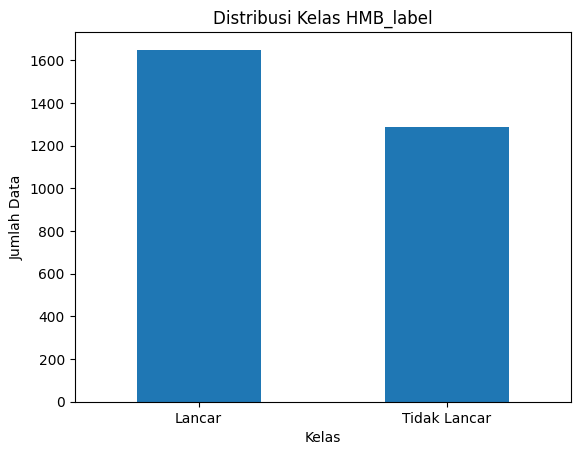

In [ ]:
y.value_counts().plot(kind='bar')
plt.title('Distribusi Kelas HMB_label')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Data')
plt.xticks([0,1], ['Lancar', 'Tidak Lancar'], rotation=0)
plt.show()

# **`Pembagian Dataset (training 80%, testing 20%)`**

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# **`Normalisasi Data`**

Untuk menyamakan skala antar fitur agar tidak ada fitur dengan nilai besar yang mendominasi proses perhitungan probabilitas pada model, sehingga model Naive Bayes dapat bekerja lebih stabil dan akurat.

In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

# **`Setting Hyperparameter (Hyperparameter Tuning) yang Digunakan`**

Proses hyperparameter tuning dilakukan menggunakan GridSearchCV dengan 5-fold cross-validation. Parameter yang dioptimasi adalah var_smoothing dengan rentang nilai logaritmik dari 1e-09 hingga 0.1, mencakup sembilan kemungkinan konfigurasi. Pemilihan F1-score sebagai scoring metric dalam tuning bertujuan memaksimalkan keseimbangan antara precision dan recall, khususnya untuk kelas minoritas "tidak lancar" yang memiliki signifikansi lebih tinggi.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB

param_grid = {
    'var_smoothing': np.logspace(-9, -1, 9)
}

grid = GridSearchCV(
    GaussianNB(),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(x_train_scaled, y_train)

print("Best var_smoothing:", grid.best_params_)
print("Best CV F1-score:", grid.best_score_)

Best var_smoothing: {'var_smoothing': np.float64(0.1)}
Best CV F1-score: 0.711614560885651


# **`Training Model Terbaik`**

Untuk mengambil model Naive Bayes terbaik hasil Grid Search (berdasarkan nilai var_smoothing terbaik), lalu melatih ulang model tersebut menggunakan seluruh data training.

In [ ]:
best_model = grid.best_estimator_
best_model.fit(x_train_scaled, y_train)

GaussianNB(var_smoothing=np.float64(0.1))

# **`Prediksi Data Uji`**

In [ ]:
y_pred = best_model.predict(x_test_scaled)

# **`Evaluasi Model`**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5595238095238095
              precision    recall  f1-score   support

           0       0.43      0.01      0.02       258
           1       0.56      0.99      0.72       330

    accuracy                           0.56       588
   macro avg       0.49      0.50      0.37       588
weighted avg       0.50      0.56      0.41       588



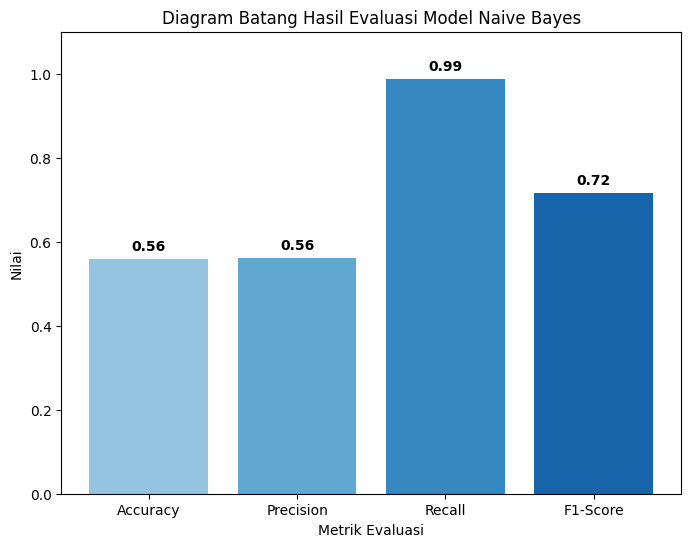

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Hitung metrik evaluasi
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Nama metrik & nilainya
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]

# Warna gradasi biru
colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(metrics)))

plt.figure(figsize=(8, 6))
plt.bar(metrics, values, color=colors)

# Tampilkan nilai di atas batang
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.ylim(0, 1.1)
plt.xlabel('Metrik Evaluasi')
plt.ylabel('Nilai')
plt.title('Diagram Batang Hasil Evaluasi Model Naive Bayes')
plt.show()

# **`Confusion Matrix`**

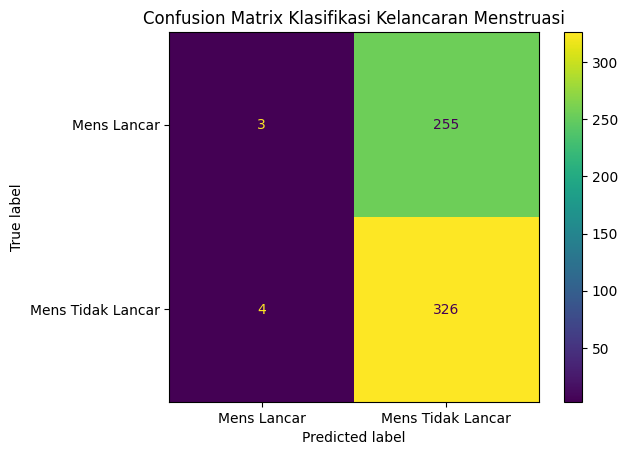

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Mens Lancar', 'Mens Tidak Lancar']
)

disp.plot()
plt.title('Confusion Matrix Klasifikasi Kelancaran Menstruasi')
plt.show()